#           **************Sales Analysis Project*****************

# Sales Performance Analysis

## Business Objective

### The objective of this project is to analyze sales data and identify top-performing products, cities, and business trends using Python and Pandas.

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load Dataset

In [2]:
df=pd.read_excel('../Data/Sales Analysis Data set.xlsx')
df

,Date,Product,Category,Qty,Rate,Sales_Amount,City
0,2025-06-25,Seeds,Chemical,34,396,13464,Kanpur
1,2026-03-10,Pesticide,Agro,8,1188,9504,Lucknow
2,2026-03-13,Pesticide,Agro,34,1151,39134,Gorakhpur
3,2025-03-03,DAP,Agro,46,728,33488,Varanasi
4,2025-08-27,Urea,Fertilizer,37,1443,53391,Gorakhpur
...,...,...,...,...,...,...,...
995,2025-02-06,Pesticide,Chemical,23,1192,27416,Gorakhpur
996,2025-12-08,Seeds,Agro,9,1332,11988,Gorakhpur
997,2026-01-24,Potash,Agro,42,1075,45150,Gorakhpur
998,2026-03-24,DAP,Fertilizer,31,498,15438,Lucknow


## Data Quality check

In [3]:
# To understanding about rows and columns in dataset
print("Dataset Shape:", df.shape)
# To checking data types of all columns
display(df.dtypes)
# Checking any null values in all columns
display(df.isnull().sum())

Dataset Shape: (1000, 7)


Date            datetime64[us]
Product                    str
Category                   str
Qty                      int64
Rate                     int64
Sales_Amount             int64
City                       str
dtype: object

Date            0
Product         0
Category        0
Qty             0
Rate            0
Sales_Amount    0
City            0
dtype: int64

#### There are No missing values were found in the dataset. Therefore, no missing-value treatment was required.

## Data Cleaning & Validation

In [4]:
# Removing extra white spaces from columns name
df.columns=df.columns.str.strip()
df.columns

Index(['Date', 'Product', 'Category', 'Qty', 'Rate', 'Sales_Amount', 'City'], dtype='str')

In [5]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Duplicate rows check
print("Duplicate Rows:", df.duplicated().sum())

# Basic statistical summary of dataset
df.describe()

Duplicate Rows: 0


,Date,Qty,Rate,Sales_Amount
count,1000,1000.000000,1000.000000,1000.00000
mean,2025-09-08 02:34:04.800000,25.047000,803.085000,20311.93800
min,2025-01-01 00:00:00,1.000000,101.000000,196.00000
25%,2025-05-09 00:00:00,13.000000,454.000000,6907.00000
50%,2025-09-06 12:00:00,24.000000,812.500000,15456.50000
75%,2026-01-10 00:00:00,37.000000,1144.250000,30115.75000
max,2026-05-16 00:00:00,50.000000,1500.000000,70080.00000
std,NaN,14.096294,399.409181,16564.64262


**Insights:** No exact duplicate records were found in the dataset. Therefore, no duplicate records were removed.

In [6]:
# Calculate total sale as per given data.
df['Total_sale']=df['Qty']*df['Rate']
# Matching value of total sale
df['Total_match']=df['Sales_Amount']==df['Total_sale']
df['Total_match'].value_counts()

Total_match
True    1000
Name: count, dtype: int64

**Insights:** Sales amount was validated against Quantity × Rate. All 1,000 transaction records matched successfully.

In [7]:
# Checking for negative rate/Qty
print("Qty <= 0:", (df['Qty'] <= 0).sum())
print("Rate <= 0:", (df['Rate'] <= 0).sum())

Qty <= 0: 0
Rate <= 0: 0


### Data Validation Summary

- No missing values were found.
- No exact duplicate records were found.
- No zero or negative quantity/rate values were found.
- Sales Amount matched Quantity × Rate for all 1,000 transactions.

The dataset is clean and ready for analysis.

## Feature Engineering
### Extract month from date column in 'YYYY-MM' format.
### Extract Year from date column


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
df[["Date", "Month"]].head()
df['Year']=df['Date'].dt.year
df

,Date,Product,Category,Qty,Rate,Sales_Amount,City,Total_sale,Total_match,Month,Year
0,2025-06-25,Seeds,Chemical,34,396,13464,Kanpur,13464,True,2025-06,2025
1,2026-03-10,Pesticide,Agro,8,1188,9504,Lucknow,9504,True,2026-03,2026
2,2026-03-13,Pesticide,Agro,34,1151,39134,Gorakhpur,39134,True,2026-03,2026
3,2025-03-03,DAP,Agro,46,728,33488,Varanasi,33488,True,2025-03,2025
4,2025-08-27,Urea,Fertilizer,37,1443,53391,Gorakhpur,53391,True,2025-08,2025
...,...,...,...,...,...,...,...,...,...,...,...
995,2025-02-06,Pesticide,Chemical,23,1192,27416,Gorakhpur,27416,True,2025-02,2025
996,2025-12-08,Seeds,Agro,9,1332,11988,Gorakhpur,11988,True,2025-12,2025
997,2026-01-24,Potash,Agro,42,1075,45150,Gorakhpur,45150,True,2026-01,2026
998,2026-03-24,DAP,Fertilizer,31,498,15438,Lucknow,15438,True,2026-03,2026


## Order_Size — Categorize on the basis of Qty
## Qty Order_Size 1–10 Small, 11–30 Medium, 31+ Large


In [9]:
def qty_category(Qty):
    if Qty<=10:
        return 'SMALL'
    elif Qty<=30:
        return 'Medium'
    else:
        return 'LARGE'
df['Order_size']=df['Qty'].apply(qty_category)
df


,Date,Product,Category,Qty,Rate,Sales_Amount,City,Total_sale,Total_match,Month,Year,Order_size
0,2025-06-25,Seeds,Chemical,34,396,13464,Kanpur,13464,True,2025-06,2025,LARGE
1,2026-03-10,Pesticide,Agro,8,1188,9504,Lucknow,9504,True,2026-03,2026,SMALL
2,2026-03-13,Pesticide,Agro,34,1151,39134,Gorakhpur,39134,True,2026-03,2026,LARGE
3,2025-03-03,DAP,Agro,46,728,33488,Varanasi,33488,True,2025-03,2025,LARGE
4,2025-08-27,Urea,Fertilizer,37,1443,53391,Gorakhpur,53391,True,2025-08,2025,LARGE
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-02-06,Pesticide,Chemical,23,1192,27416,Gorakhpur,27416,True,2025-02,2025,Medium
996,2025-12-08,Seeds,Agro,9,1332,11988,Gorakhpur,11988,True,2025-12,2025,SMALL
997,2026-01-24,Potash,Agro,42,1075,45150,Gorakhpur,45150,True,2026-01,2026,LARGE
998,2026-03-24,DAP,Fertilizer,31,498,15438,Lucknow,15438,True,2026-03,2026,LARGE


## Total orders count in each category

In [10]:
df_total_ordersize=df['Order_size'].value_counts().reset_index()
df_total_ordersize


,Order_size,count
0,Medium,431
1,LARGE,371
2,SMALL,198


## Overall sales performance
## Calculating Total Sales Revenue.

In [11]:
df_totalsale=df['Total_sale'].sum()
print("Total Sales revenue is:" , df_totalsale)

Total Sales revenue is: 20311938


## Calculating Total Quantity Sold.

In [12]:
df_totalqty=df['Qty'].sum()
print("Total Sold Qty is:" , df_totalqty)

Total Sold Qty is: 25047


## Calculating Average Order Value.

In [13]:
df_meanvalue=df['Total_sale'].mean()
print("Average order value is:" , df_meanvalue)

Average order value is: 20311.938


## Find out Highest and Lowest Single Order Value

In [14]:
df_highest=df['Total_sale'].max()
df_lowest=df['Total_sale'].min()
print("Highest Single order value is:" , df_highest)
print("Lowest Single order value is:" , df_lowest)
df.loc[df['Sales_Amount']==df_lowest]
df.loc[df['Sales_Amount']==df_highest]

Highest Single order value is: 70080
Lowest Single order value is: 196


,Date,Product,Category,Qty,Rate,Sales_Amount,City,Total_sale,Total_match,Month,Year,Order_size
753,2025-04-09,Potash,Chemical,48,1460,70080,Gorakhpur,70080,True,2025-04,2025,LARGE


## Product-wise Sales Analysis

## Calculation perform for each product

### Total Sales
### Total Quantity Sold
### Average Sales per Order

In [15]:
df_prod_wise_analysis=df.groupby(df['Product']).agg(
    Total_sale=('Total_sale','sum'),
    Total_qty_sold=('Qty','sum'),
    Average_sales_per_order=('Total_sale','mean')
).reset_index().round(2)
df_prod_wise_analysis

,Product,Total_sale,Total_qty_sold,Average_sales_per_order
0,DAP,4195696,5259,19979.50
1,Pesticide,4671771,5676,21235.32
2,Potash,4335447,5024,21786.17
3,Seeds,3555317,4485,19322.38
4,Urea,3553707,4603,19003.78


## 2. Ranking as per total sales.

In [16]:
df_prod_wise_analysis['Sales_Rank']=df_prod_wise_analysis['Total_sale'].rank(ascending=False)
df_prod_wise_analysis.sort_values('Sales_Rank')

,Product,Total_sale,Total_qty_sold,Average_sales_per_order,Sales_Rank
1,Pesticide,4671771,5676,21235.32,1.0
2,Potash,4335447,5024,21786.17,2.0
0,DAP,4195696,5259,19979.50,3.0
3,Seeds,3555317,4485,19322.38,4.0
4,Urea,3553707,4603,19003.78,5.0


## 3. Top-performing product

In [17]:
top_prod=df_prod_wise_analysis.loc[df_prod_wise_analysis['Sales_Rank']==1]
top_prod

,Product,Total_sale,Total_qty_sold,Average_sales_per_order,Sales_Rank
1,Pesticide,4671771,5676,21235.32,1.0


## 4. Lowest revenue product

In [18]:
low_rev_prod = df_prod_wise_analysis.sort_values('Total_sale',ascending=True).head(1)
low_rev_prod

,Product,Total_sale,Total_qty_sold,Average_sales_per_order,Sales_Rank
4,Urea,3553707,4603,19003.78,5.0


## Top Product Contribution (%)
### Contribution %= Top Product sale/Total Sale*100

In [19]:
df
cont_percentage=(top_prod['Total_sale'].iloc[0]/df_totalsale*100).round(2)
cont_percentage

np.float64(23.0)

In [20]:
Top_prod_name=top_prod['Product'].iloc[0]
Top_prod_sale=top_prod['Total_sale'].iloc[0]
low_prod_name=low_rev_prod['Product'].iloc[0]
low_prod_sale=low_rev_prod['Total_sale'].iloc[0]
print(f'Top Performing Product is: {Top_prod_name} | Total Sale: {Top_prod_sale:,}')
print(f'Lowest Revenue Product is: {low_prod_name} | Total Sale: {low_prod_sale:,}')
print(f'Top Performing product {Top_prod_name} is contributed in Total Sale: {cont_percentage} %')

Top Performing Product is: Pesticide | Total Sale: 4,671,771
Lowest Revenue Product is: Urea | Total Sale: 3,553,707
Top Performing product Pesticide is contributed in Total Sale: 23.0 %


# City-wise Analysis
### Total Sales
### Total Quantity Sold
### Total Orders
### Average Order Value

In [21]:
df
city_wise_analysis=df.groupby(df['City']).agg(
    Total_Sale=('Total_sale','sum'),
    Total_qty_sold=('Qty','sum'),
    Average_order_value=('Total_sale','mean'),
    Total_Transaction=('Total_sale','count')
).reset_index().round(2)
city_wise_analysis



,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction
0,Deoria,3672230,4645,19849.89,185
1,Gorakhpur,4076146,5019,20586.60,198
2,Kanpur,4120006,5054,20497.54,201
3,Lucknow,3823746,4922,18836.19,203
4,Varanasi,4619810,5407,21689.25,213


## Highest selling city

In [22]:
highest_city = city_wise_analysis.loc[
    city_wise_analysis["Total_Sale"] == city_wise_analysis["Total_Sale"].max()
]
highest_city

,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction
4,Varanasi,4619810,5407,21689.25,213


## Lowes selling city

In [23]:
lowest_city=city_wise_analysis.loc[city_wise_analysis["Total_Sale"] == city_wise_analysis['Total_Sale'].min()]
lowest_city

,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction
0,Deoria,3672230,4645,19849.89,185


In [24]:
highest_city_name=highest_city["City"].iloc[0]
lowest_city_name=lowest_city["City"].iloc[0]
highest_city_rev=highest_city["Total_Sale"].iloc[0]
lowest_city_rev=lowest_city["Total_Sale"].iloc[0]
highest_city_name,lowest_city_name,highest_city_rev,lowest_city_rev
print(f'Highest Revenue City: {highest_city_name} | Revenue: {highest_city_rev:,}')
print(f'Lowest Revenue City: {lowest_city_name} | Revenue: {lowest_city_rev:,}')

Highest Revenue City: Varanasi | Revenue: 4,619,810
Lowest Revenue City: Deoria | Revenue: 3,672,230


## Contribution % of Varanasi in Total Sales.
## Contribution % of Deoria in Total Sales.

In [25]:
highest_contribution=(highest_city_rev/df_totalsale*100).round(2)
lowest_contribution=(lowest_city_rev/df_totalsale*100).round(2)
highest_contribution, lowest_contribution
print(f'{highest_city_name} contributed {highest_contribution} % of Total Sales.')
print(f'{lowest_city_name} contributes {lowest_contribution} % of Total Sales.')

Varanasi contributed 22.74 % of Total Sales.
Deoria contributes 18.08 % of Total Sales.


## Sales ranking in City wise analysis

In [26]:
city_wise_analysis['Sales_Rank']=city_wise_analysis['Total_Sale'].rank(ascending=False)
city_wise_analysis.sort_values('Sales_Rank')

,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction,Sales_Rank
4,Varanasi,4619810,5407,21689.25,213,1.0
2,Kanpur,4120006,5054,20497.54,201,2.0
1,Gorakhpur,4076146,5019,20586.60,198,3.0
3,Lucknow,3823746,4922,18836.19,203,4.0
0,Deoria,3672230,4645,19849.89,185,5.0


## Marking revenue Category

In [27]:
def rev_category(Sales_Rank):
    if Sales_Rank<=2.0:
        return 'High Revenue'
    elif Sales_Rank>2.0 and Sales_Rank<=4.0:
        return "Medium Revenue"
    else:
        return "Low Revenue"

city_wise_analysis['Revenue_Category']=city_wise_analysis['Sales_Rank'].apply(rev_category)
city_wise_analysis.sort_values('Sales_Rank')

,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction,Sales_Rank,Revenue_Category
4,Varanasi,4619810,5407,21689.25,213,1.0,High Revenue
2,Kanpur,4120006,5054,20497.54,201,2.0,High Revenue
1,Gorakhpur,4076146,5019,20586.60,198,3.0,Medium Revenue
3,Lucknow,3823746,4922,18836.19,203,4.0,Medium Revenue
0,Deoria,3672230,4645,19849.89,185,5.0,Low Revenue


## Find out Highest Ordered City and lowest ordered city with value and business insights

In [28]:
city_wise_analysis
high_order=city_wise_analysis['Total_Transaction'].max()
low_order=city_wise_analysis['Total_Transaction'].min()
high_order,low_order
high_order_city=city_wise_analysis.loc[city_wise_analysis['Total_Transaction']==city_wise_analysis['Total_Transaction'].max()]
low_order_city=city_wise_analysis.loc[city_wise_analysis['Total_Transaction']==city_wise_analysis['Total_Transaction'].min()]
high_order_city
high_order_city_name=high_order_city.iloc[0]['City']
low_order_city_name=low_order_city.iloc[0]['City']
high_order_city_name,low_order_city_name

('Varanasi', 'Deoria')

## Contribution % of each city in total sales

In [29]:
city_wise_analysis['Revenue_Share_%'] = round((city_wise_analysis['Total_Sale'] / df_totalsale) * 100,2)
city_wise_analysis.sort_values('Sales_Rank')

,City,Total_Sale,Total_qty_sold,Average_order_value,Total_Transaction,Sales_Rank,Revenue_Category,Revenue_Share_%
4,Varanasi,4619810,5407,21689.25,213,1.0,High Revenue,22.74
2,Kanpur,4120006,5054,20497.54,201,2.0,High Revenue,20.28
1,Gorakhpur,4076146,5019,20586.60,198,3.0,Medium Revenue,20.07
3,Lucknow,3823746,4922,18836.19,203,4.0,Medium Revenue,18.83
0,Deoria,3672230,4645,19849.89,185,5.0,Low Revenue,18.08


## Business Insights

In [30]:
print(f'Highest Ordered City: {high_order_city_name} | Total Order: {high_order}.')
print(f'Lowest Ordered City: {low_order_city_name} | Total Order: {low_order}.')
print()
print(f'{highest_city_name} generated the highest Revenue of Rs.{highest_city_rev:,}.')
print(f'{highest_city_name} Contributed {highest_contribution:,} % of Total Sales.')
print(f'{lowest_city_name} generated the lowest Revenue of Rs.{lowest_city_rev:,}.' )
print(f'{lowest_city_name} required focused marketing and sales improvement strategies.')

Highest Ordered City: Varanasi | Total Order: 213.
Lowest Ordered City: Deoria | Total Order: 185.

Varanasi generated the highest Revenue of Rs.4,619,810.
Varanasi Contributed 22.74 % of Total Sales.
Deoria generated the lowest Revenue of Rs.3,672,230.
Deoria required focused marketing and sales improvement strategies.


## Category wise analysis*************
### Find out category wise Total Sales,Total Quantity Sold,Average Order Value & Total Orders.

In [31]:
df
category_wise_analysis=df.groupby(df['Category']).agg(
    Total_Sale=('Total_sale', 'sum'),
    Total_Qty_sold=('Qty', 'sum'),
    Avg_Order_value=('Total_sale','mean'),
    Total_Transaction=('Total_sale','count')
).reset_index().round(2)
category_wise_analysis

,Category,Total_Sale,Total_Qty_sold,Avg_Order_value,Total_Transaction
0,Agro,6320798,7783,20455.66,309
1,Chemical,6587344,8221,19374.54,340
2,Fertilizer,7403796,9043,21093.44,351


## Now Find out Highest and lowest revenue category

In [32]:
category_wise_analysis
highest_rev_category=category_wise_analysis.loc[category_wise_analysis['Total_Sale']==category_wise_analysis['Total_Sale'].max()]
highest_rev_category
highest_category_name=highest_rev_category.iloc[0]['Category']
highest_category_rev=highest_rev_category.iloc[0]['Total_Sale']
highest_category_name, highest_category_rev
lowest_rev_category=category_wise_analysis.loc[category_wise_analysis['Total_Sale']==category_wise_analysis['Total_Sale'].min()]
lowest_rev_category
lowest_category_name=lowest_rev_category.iloc[0]['Category']
lowest_category_rev=lowest_rev_category.iloc[0]['Total_Sale']
lowest_category_name, lowest_category_rev
print(f'Highest Revenue Category: {highest_category_name} | Revenue: ₹{highest_category_rev:,}.')
print(f'Lowest Revenue Category: {lowest_category_name} | Revenue: ₹{lowest_category_rev:,}.')

Highest Revenue Category: Fertilizer | Revenue: ₹7,403,796.
Lowest Revenue Category: Agro | Revenue: ₹6,320,798.


## Now find out highest and lowest order category

In [33]:
category_wise_analysis
highest_order_row=category_wise_analysis.loc[category_wise_analysis['Total_Transaction']==category_wise_analysis['Total_Transaction'].max()]
highest_order_row
lowest_order_row=category_wise_analysis.loc[category_wise_analysis['Total_Transaction']==category_wise_analysis['Total_Transaction'].min()]
lowest_order_row
highest_order_categ_name=highest_order_row.iloc[0]['Category']
lowest_order_categ_name=lowest_order_row.iloc[0]['Category']
highest_order_count=highest_order_row.iloc[0]['Total_Transaction']
lowest_order_count=lowest_order_row.iloc[0]['Total_Transaction']
print(f'Highest Order Category: {highest_order_categ_name} | Total Transaction: {highest_order_count:,}.')
print(f'Lowest Order Category: {lowest_order_categ_name} | Total Transaction: {lowest_order_count:,}.')

Highest Order Category: Fertilizer | Total Transaction: 351.
Lowest Order Category: Agro | Total Transaction: 309.


## Find out contribution % category wise

In [34]:
category_wise_analysis
highest_category_contribution=(highest_category_rev/df_totalsale*100).round(2)
lowest_category_contribution=(lowest_category_rev/df_totalsale*100).round(2)
print(f'{highest_category_name} contributed {highest_category_contribution:,} % of Total Sales.')
print(f'{lowest_category_name} contributed {lowest_category_contribution:,} % of Total Sales.')


Fertilizer contributed 36.45 % of Total Sales.
Agro contributed 31.12 % of Total Sales.


## Sales Ranking category wise

In [35]:
category_wise_analysis['Sales_rank']=category_wise_analysis['Total_Sale'].rank(ascending=False)
category_wise_analysis

,Category,Total_Sale,Total_Qty_sold,Avg_Order_value,Total_Transaction,Sales_rank
0,Agro,6320798,7783,20455.66,309,3.0
1,Chemical,6587344,8221,19374.54,340,2.0
2,Fertilizer,7403796,9043,21093.44,351,1.0


## Revenue category assign accourding to sales rank

In [36]:
category_wise_analysis
def rev_category(Sales_rank):
    if Sales_rank==1.0:
        return "High Revenue"
    elif Sales_rank==2.0:
        return "Medium Revenue"
    else:
        return "Low Revenue"
category_wise_analysis["Rev_category"]=category_wise_analysis['Sales_rank'].apply(rev_category)
category_wise_analysis

,Category,Total_Sale,Total_Qty_sold,Avg_Order_value,Total_Transaction,Sales_rank,Rev_category
0,Agro,6320798,7783,20455.66,309,3.0,Low Revenue
1,Chemical,6587344,8221,19374.54,340,2.0,Medium Revenue
2,Fertilizer,7403796,9043,21093.44,351,1.0,High Revenue


## Revenue share calculate for every category

In [37]:
category_wise_analysis
def calc_rev_share(Total_Sale):
    return (Total_Sale/df_totalsale*100).round(2)
category_wise_analysis['Rev_share %']=category_wise_analysis["Total_Sale"].apply(calc_rev_share)
category_wise_analysis

,Category,Total_Sale,Total_Qty_sold,Avg_Order_value,Total_Transaction,Sales_rank,Rev_category,Rev_share %
0,Agro,6320798,7783,20455.66,309,3.0,Low Revenue,31.12
1,Chemical,6587344,8221,19374.54,340,2.0,Medium Revenue,32.43
2,Fertilizer,7403796,9043,21093.44,351,1.0,High Revenue,36.45


## Final Category wise Business Insights:----

In [38]:
print(f'Highest Revenue Category: {highest_category_name} | Total Revenue: Rs.{highest_category_rev:,}.')
print(f'Lowest Revenue Category: {lowest_category_name} | Total Revenue: Rs.{lowest_category_rev:,}.')
print(f'Highest Ordered category is {highest_order_categ_name} | Total Transaction: {highest_order_count:,}.')
print(f'Lowest Ordered category is {lowest_order_categ_name} | Total Transaction: {lowest_order_count:,}.')
print()
print(f"**Conclusion**: {highest_category_name} category's products contribute {highest_category_contribution:,} % of Total Sales and all others category's products need to be focused on marketing strategy and also track the market behaviour/demand because {lowest_category_name} category's product contributed {lowest_category_contribution:,} % of Total Sales. So basically we have to need more focused on {lowest_category_name} category. ")

Highest Revenue Category: Fertilizer | Total Revenue: Rs.7,403,796.
Lowest Revenue Category: Agro | Total Revenue: Rs.6,320,798.
Highest Ordered category is Fertilizer | Total Transaction: 351.
Lowest Ordered category is Agro | Total Transaction: 309.

**Conclusion**: Fertilizer category's products contribute 36.45 % of Total Sales and all others category's products need to be focused on marketing strategy and also track the market behaviour/demand because Agro category's product contributed 31.12 % of Total Sales. So basically we have to need more focused on Agro category. 


## Monthly Based Analysis*********
### Month
### Total Sales
### Total Quantity Sold
### Average Order Value
### Total Orders

In [39]:
df['Date']=pd.to_datetime(df['Date'],format='%Y-%m-%d')
df['Month'] = df['Date'].dt.to_period('M')
df['Year']=df['Date'].dt.to_period('Y')
df
monthly_based_analysis=df.groupby(['Year','Month']).agg(
    Total_sale=('Total_sale','sum'),
    Total_qty_sold=('Qty','sum'),
    Avg_order_value=('Total_sale','mean'),
    Total_Transaction=('Total_sale','count')
).reset_index()
monthly_based_analysis['Month']=monthly_based_analysis['Month'].dt.strftime('%b-%y')
monthly_based_analysis['Avg_order_value']=monthly_based_analysis['Avg_order_value'].round(2)
monthly_based_analysis

,Year,Month,Total_sale,Total_qty_sold,Avg_order_value,Total_Transaction
0,2025,Jan-25,1001744,1220,19264.31,52
1,2025,Feb-25,836048,1240,16393.10,51
2,2025,Mar-25,1212202,1463,19241.30,63
3,2025,Apr-25,1307702,1630,18681.46,70
4,2025,May-25,1043773,1167,20466.14,51
5,2025,Jun-25,1046865,1406,16884.92,62
6,2025,Jul-25,1509272,1813,22195.18,68
7,2025,Aug-25,1569410,1767,24144.77,65
8,2025,Sep-25,1539402,1869,21380.58,72
9,2025,Oct-25,919695,1287,15328.25,60


## Finding out highest and lowest 'revenue month','Order Month' and revenue contribution percentage.

In [40]:
monthly_based_analysis
highest_rev_month=monthly_based_analysis.loc[monthly_based_analysis['Total_sale']==monthly_based_analysis['Total_sale'].max()]
highest_monthly_revenue=highest_rev_month.iloc[0]['Total_sale']
lowest_rev_month=monthly_based_analysis.loc[monthly_based_analysis['Total_sale']==monthly_based_analysis['Total_sale'].min()]
lowest_monthly_revenue=lowest_rev_month.iloc[0]['Total_sale']
highest_order_month=monthly_based_analysis.loc[monthly_based_analysis['Total_Transaction']==monthly_based_analysis['Total_Transaction'].max()]
highest_monthly_order_name=highest_order_month.iloc[0]['Month']
lowest_order_month=monthly_based_analysis.loc[monthly_based_analysis['Total_Transaction']==monthly_based_analysis['Total_Transaction'].min()]
lowest_monthly_order_name=lowest_order_month.iloc[0]['Month']
highest_rev_month_name=highest_rev_month.iloc[0]['Month']
lowest_rev_month_name=lowest_rev_month.iloc[0]['Month']
highest_monthly_order_count=highest_order_month.iloc[0]['Total_Transaction']
lowest_monthly_order_count=lowest_order_month.iloc[0]['Total_Transaction']
highest_contribution_monthly=(highest_monthly_revenue/df_totalsale*100).round(2)
lowest_contribution_monthly=(lowest_monthly_revenue/df_totalsale*100).round(2)
print(f'Best Sales Month: {highest_rev_month_name} | Revenue: ₹ {highest_monthly_revenue:,}.')
print(f'Worst Sales Month: {lowest_rev_month_name} | Revenue: ₹ {lowest_monthly_revenue:,}.')
print(f'Highest order receive in Month: {highest_monthly_order_name} | Total Transaction: {highest_monthly_order_count:,}.')
print(f'Lowest order receive in Month: {lowest_monthly_order_name} | Total Transaction: {lowest_monthly_order_count:,}.')
print(f'Best Month {highest_rev_month_name} contributed {highest_contribution_monthly} % in Total Sale.')
print(f'Worst Month {lowest_rev_month_name} contributed {lowest_contribution_monthly} % in Total Sale.')


Best Sales Month: Aug-25 | Revenue: ₹ 1,569,410.
Worst Sales Month: May-26 | Revenue: ₹ 445,671.
Highest order receive in Month: Jan-26 | Total Transaction: 74.
Lowest order receive in Month: May-26 | Total Transaction: 22.
Best Month Aug-25 contributed 7.73 % in Total Sale.
Worst Month May-26 contributed 2.19 % in Total Sale.


## Business Insights:

In [41]:
print()

print(f"{highest_rev_month_name} recorded the highest monthly revenue of ₹{highest_monthly_revenue:,}, contributing {highest_contribution_monthly}% of the total sales.")

print(f"{lowest_rev_month_name} recorded the lowest monthly revenue of ₹{lowest_monthly_revenue:,}, contributing only {lowest_contribution_monthly}% of the total sales.")

print(f"{highest_monthly_order_name} received the highest number of customer orders {highest_monthly_order_count}, indicating strong customer demand.")

print(f"{lowest_monthly_order_name} received the fewest orders ({lowest_monthly_order_count}), suggesting that additional marketing or promotional efforts may be required during this period.")


Aug-25 recorded the highest monthly revenue of ₹1,569,410, contributing 7.73% of the total sales.
May-26 recorded the lowest monthly revenue of ₹445,671, contributing only 2.19% of the total sales.
Jan-26 received the highest number of customer orders 74, indicating strong customer demand.
May-26 received the fewest orders (22), suggesting that additional marketing or promotional efforts may be required during this period.


# City wise revenue trend Visualisation

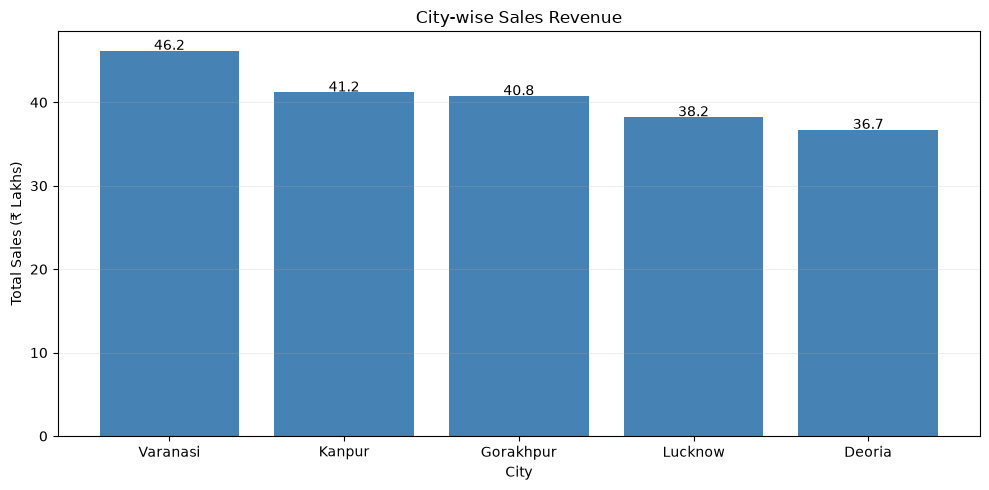

In [42]:
city_chart = city_wise_analysis.sort_values('Total_Sale', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_chart['City'],city_chart['Total_Sale'] / 100000,color='steelblue')
plt.title('City-wise Sales Revenue')
plt.xlabel('City')
plt.ylabel('Total Sales (₹ Lakhs)')
plt.grid(axis='y', alpha=0.2)

for i, value in enumerate(city_chart['Total_Sale'] / 100000):
    plt.text(i, value + 0.1, f'{value:.1f}', ha='center')

plt.tight_layout()
plt.savefig(r"C:\Users\admin\OneDrive\Desktop\sales-performance-analysis-python\Images\City_wise_revenue.png",dpi=300,bbox_inches='tight')
plt.show()

**Insight:** Varanasi generated the highest sales revenue of approximately ₹46.2 lakh, while Deoria generated the lowest revenue of approximately ₹36.7 lakh. The gap indicates an opportunity to investigate demand, product mix, and sales coverage in Deoria.

## Monthly trend Visualisation


### Monthly Sales Trend (Line Chart)

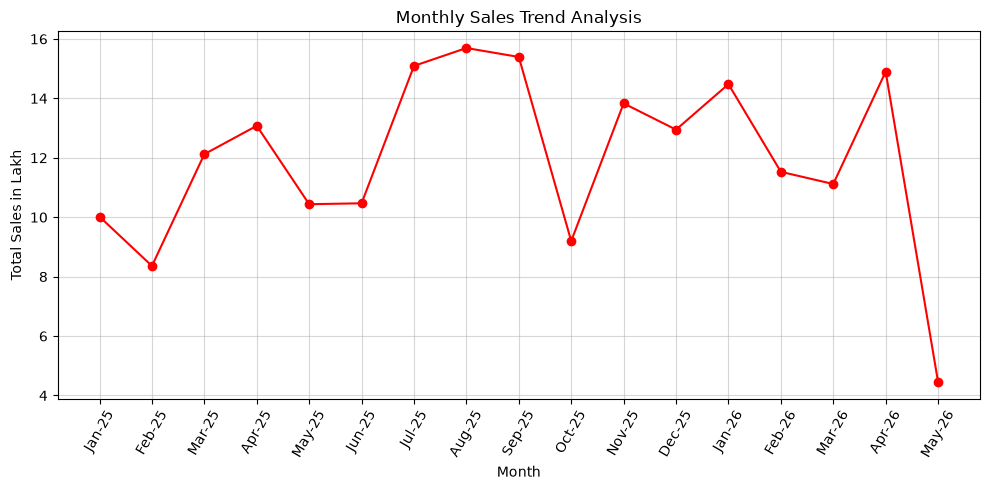

In [43]:
plt.figure(figsize=(10,5))
plt.plot(monthly_based_analysis['Month'],monthly_based_analysis['Total_sale']/100000,marker='o',color='red')
plt.title('Monthly Sales Trend Analysis')
plt.xlabel('Month')
plt.ylabel('Total Sales in Lakh')
plt.grid(alpha=0.5)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Month-on-Month (MoM) Sales Growth %

In [44]:
monthly_based_analysis['MoM_Growth_%'] = (monthly_based_analysis['Total_sale'].pct_change() * 100).round(2)
monthly_based_analysis

,Year,Month,Total_sale,Total_qty_sold,Avg_order_value,Total_Transaction,MoM_Growth_%
0,2025,Jan-25,1001744,1220,19264.31,52,NaN
1,2025,Feb-25,836048,1240,16393.10,51,-16.54
2,2025,Mar-25,1212202,1463,19241.30,63,44.99
3,2025,Apr-25,1307702,1630,18681.46,70,7.88
4,2025,May-25,1043773,1167,20466.14,51,-20.18
5,2025,Jun-25,1046865,1406,16884.92,62,0.30
6,2025,Jul-25,1509272,1813,22195.18,68,44.17
7,2025,Aug-25,1569410,1767,24144.77,65,3.98
8,2025,Sep-25,1539402,1869,21380.58,72,-1.91
9,2025,Oct-25,919695,1287,15328.25,60,-40.26


## MoM Growth Chart

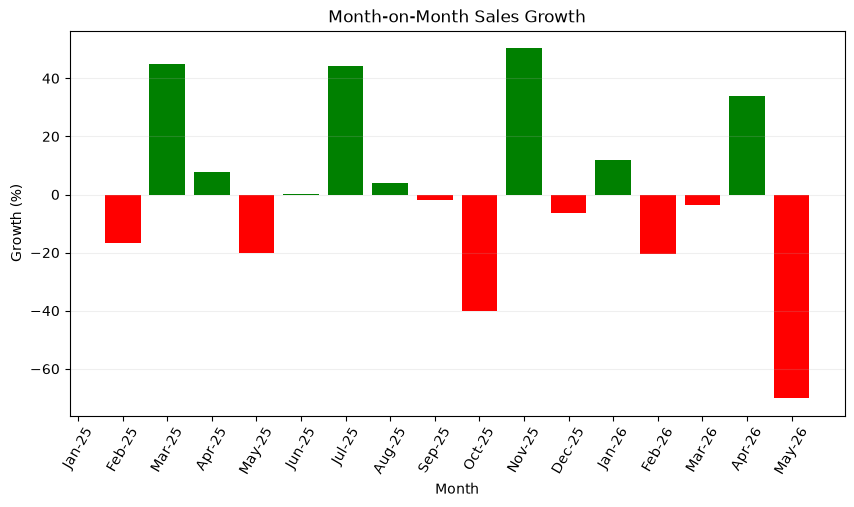

In [45]:
plt.figure(figsize=(10,5))

colors = ['green' if value >= 0 else 'red'
          for value in monthly_based_analysis['MoM_Growth_%']]

plt.bar(monthly_based_analysis['Month'],monthly_based_analysis['MoM_Growth_%'],color=colors)
plt.title('Month-on-Month Sales Growth')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.xticks(rotation=60)
plt.grid(axis='y', alpha=0.2)
plt.show()

**Insight:** Sales growth was highly volatile. The strongest growth was recorded in November 2025 (+50.39%), while May 2026 showed the sharpest decline (-70.09%). This decline should be investigated for possible demand, inventory, pricing, or seasonal factors.

## Monthly Orders Bar Chart

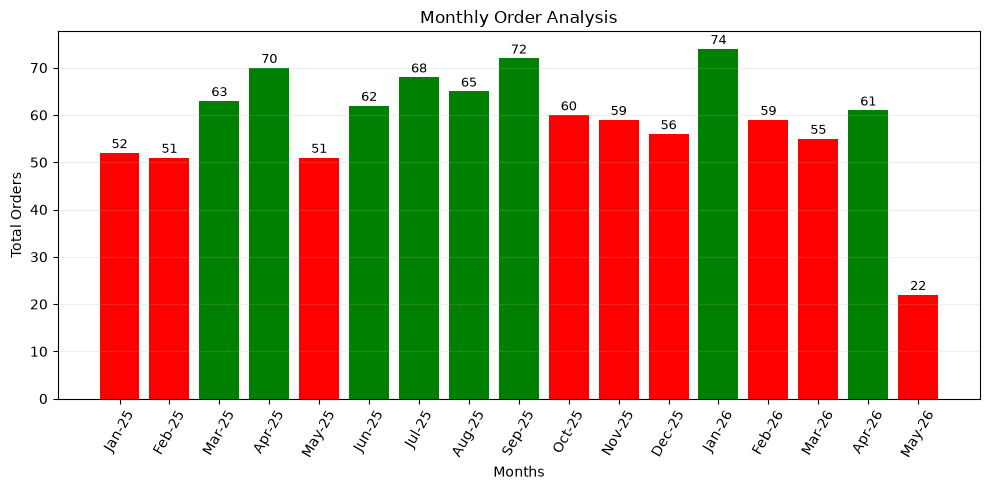

In [47]:
plt.figure(figsize=(10,5))
colors=[]
for order in monthly_based_analysis['Total_Transaction']:
    if order >60:
        colors.append('green')
    else:
        colors.append('red')
plt.bar(monthly_based_analysis['Month'],monthly_based_analysis['Total_Transaction'],color=colors)
plt.title('Monthly Order Analysis')
plt.xlabel('Months')
plt.ylabel('Total Orders')
plt.xticks(rotation=60)
plt.grid(axis='y',alpha=0.2)
plt.tight_layout()
for i, value in enumerate(monthly_based_analysis['Total_Transaction']):
    plt.text(i, value + 1, str(value), ha='center', fontsize=9)
plt.show()

## Monthly Quantity Sold (Bar Chart)


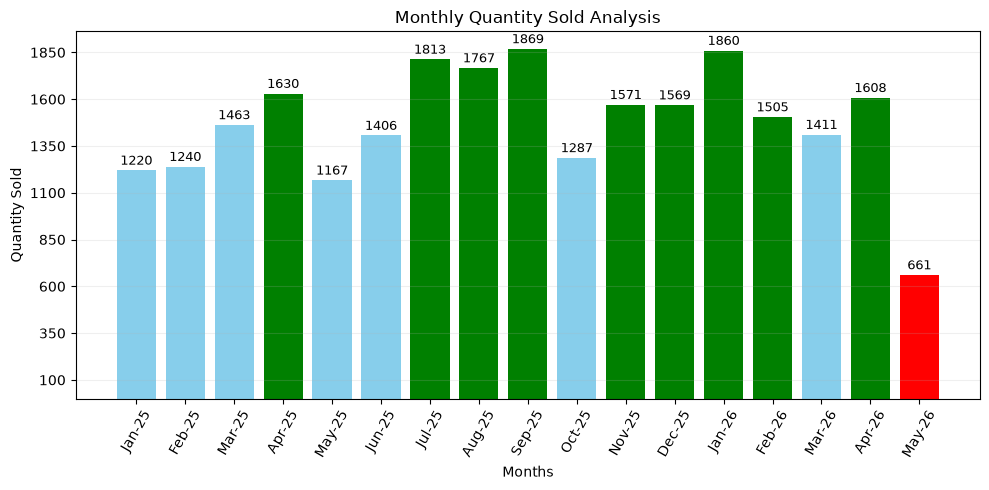

In [48]:
plt.figure(figsize=(10,5))
colors=[]
for Quantity in monthly_based_analysis['Total_qty_sold']:
    if Quantity >1500:
        colors.append('green')
    elif Quantity<1500 and Quantity >1000:
        colors.append('skyblue')
    else:
        colors.append('red')
plt.bar(monthly_based_analysis['Month'],monthly_based_analysis['Total_qty_sold'],color=colors)
plt.title('Monthly Quantity Sold Analysis')
plt.xlabel('Months')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=60)
plt.yticks(np.arange(100,2000,250))
plt.grid(axis='y',alpha=0.2)
plt.tight_layout()
for i, value in enumerate(monthly_based_analysis['Total_qty_sold']):
    plt.text(i, value + 30, str(value), ha='center', fontsize=9)
plt.show()

## Average Order Value Trend (Line Ch)

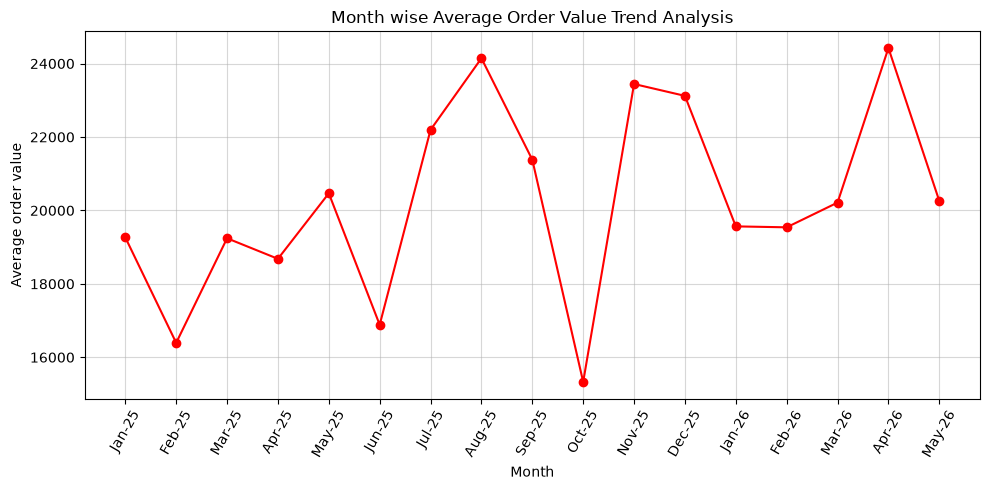

In [49]:
plt.figure(figsize=(10,5))
plt.plot(monthly_based_analysis['Month'],monthly_based_analysis['Avg_order_value'],marker='o',color='red')
plt.title('Month wise Average Order Value Trend Analysis')
plt.grid(alpha=0.5)
plt.xlabel('Month')
plt.xticks(rotation=60)
plt.ylabel('Average order value')
plt.tight_layout()
plt.show()

## Category Revenue Share (Pie Chart)

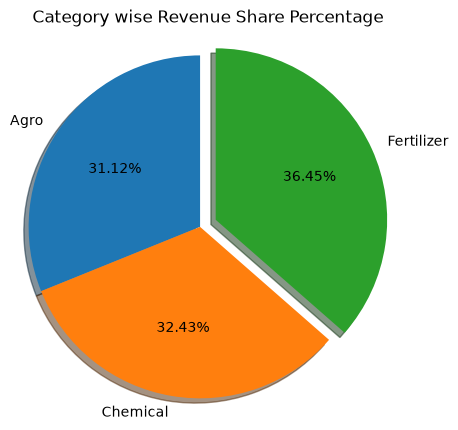

In [50]:
plt.figure(figsize=(5,5))
plt.pie(category_wise_analysis['Rev_share %'],labels=category_wise_analysis['Category'],autopct='%.2f%%',startangle=90,explode=[0.0,0.0,0.1],shadow=True)
plt.title('Category wise Revenue Share Percentage')
plt.axis('equal')
plt.show()


## Product-wise Revenue Analysis

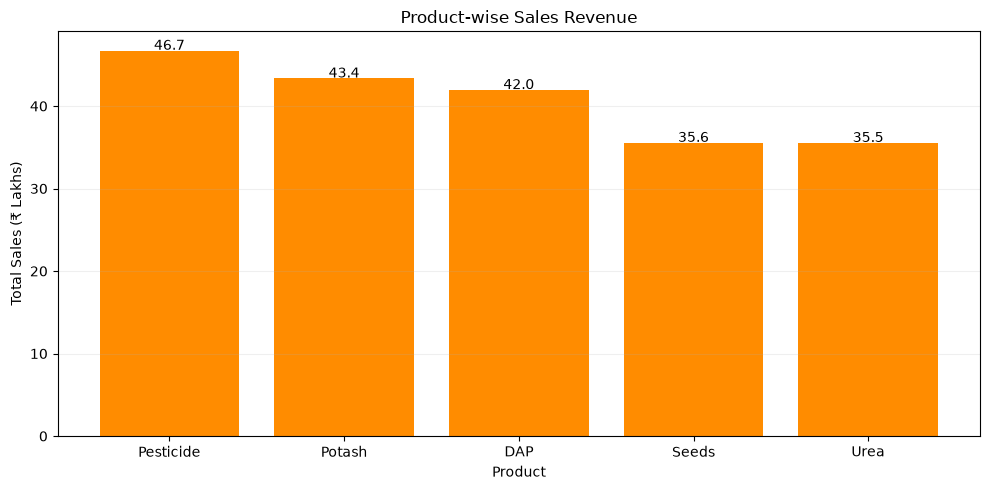

In [51]:
product_chart = df_prod_wise_analysis.sort_values('Total_sale',ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(product_chart['Product'],product_chart['Total_sale'] / 100000,color='darkorange')
plt.title('Product-wise Sales Revenue')
plt.xlabel('Product')
plt.ylabel('Total Sales (₹ Lakhs)')
plt.grid(axis='y', alpha=0.2)

for i, value in enumerate(product_chart['Total_sale'] / 100000):
    plt.text(i, value + 0.1, f'{value:.1f}', ha='center')

plt.tight_layout()
plt.show()

**Insight:** Pesticide was the highest-revenue product, generating approximately ₹46.7 lakh in sales. Urea was the lowest-revenue product at approximately ₹35.5 lakh. However, the difference between products is relatively small, indicating a balanced product-revenue mix.

# Final Business Summary

## Key Business Findings

- The analysis covered 1,000 clean sales transactions from January 2025 to May 2026, with no missing values, duplicate records, invalid quantity/rate values, or sales-calculation mismatches.
- Total sales revenue was approximately ₹2.03 crore across five cities and five agricultural products.
- Pesticide was the top-performing product, generating ₹46.72 lakh and contributing 23% of total sales. Urea generated the lowest product revenue at ₹35.54 lakh.
- Varanasi was the highest-revenue city at approximately ₹46.2 lakh, while Deoria recorded the lowest revenue at approximately ₹36.7 lakh.
- Sales performance showed month-to-month volatility. November 2025 recorded the strongest monthly growth (+50.39%), while May 2026 showed the largest decline (-70.09%).
- The business should investigate the lower performance in Deoria and the sharp decline in May 2026 by reviewing product demand, inventory availability, pricing, and whether the May 2026 data represents a complete month.

## Business Recommendations

1. Analyze the product mix and sales approach used in Varanasi and identify practices that can be applied in Deoria.
2. Review Urea sales by city and month to identify whether lower revenue is caused by lower demand, pricing, or product availability.
3. Investigate the sales decline in May 2026 before taking action, including data-period completeness, stock availability, and seasonal demand.
4. Track Month-on-Month growth regularly to detect sales declines early and support timely business decisions.